In [1]:
import pandas as pd
from pathlib import Path

path = Path("../data/raw/cadata.txt")

# Read the whole file as text
text = path.read_text(encoding="utf-8", errors="replace")

# Keep only lines that begin with a number
valid_lines = []
for line in text.splitlines():
    s = line.strip()
    if s and s[0].isdigit():
        valid_lines.append(s)

# Build a DataFrame from the numeric rows
df_file = pd.read_csv(
    pd.io.common.StringIO("\n".join(valid_lines)),
    sep=r"\s+",
    header=None,
    engine="python"
)

# Name the columns based on the dataset description
df_file.columns = [
    "Median_House_Value",
    "Median_Income",
    "Housing_Median_Age",
    "Total_Rooms",
    "Total_Bedrooms",
    "Population",
    "Households",
    "Latitude",
    "Longitude"
]

print(df_file.head())
print(df_file.shape)
print(df_file.isnull().sum())

   Median_House_Value  Median_Income  Housing_Median_Age  Total_Rooms  \
0            452600.0         8.3252                41.0        880.0   
1            358500.0         8.3014                21.0       7099.0   
2            352100.0         7.2574                52.0       1467.0   
3            341300.0         5.6431                52.0       1274.0   
4            342200.0         3.8462                52.0       1627.0   

   Total_Bedrooms  Population  Households  Latitude  Longitude  
0           129.0       322.0       126.0     37.88    -122.23  
1          1106.0      2401.0      1138.0     37.86    -122.22  
2           190.0       496.0       177.0     37.85    -122.24  
3           235.0       558.0       219.0     37.85    -122.25  
4           280.0       565.0       259.0     37.85    -122.25  
(20640, 9)
Median_House_Value    0
Median_Income         0
Housing_Median_Age    0
Total_Rooms           0
Total_Bedrooms        0
Population            0
Households      

In [2]:
import pandas as pd
import requests

# 1. Define endpoint with query parameters (limiting to 200 records and ordering by unit count)
url = "https://data.cityofchicago.org/resource/s6ha-ppgi.json?$limit=200&$order=units DESC"

# 2. Fetch the JSON data
response = requests.get(url)
response.raise_for_status()  # Check for successful HTTP 200 response

# 3. Load directly into a DataFrame
df_api = pd.DataFrame(response.json())

# 4. Clean column types (Socrata often returns numbers as strings by default)
df_api["units"] = pd.to_numeric(df_api["units"], errors="coerce")
df_api["latitude"] = pd.to_numeric(df_api["latitude"], errors="coerce")
df_api["longitude"] = pd.to_numeric(df_api["longitude"], errors="coerce")

# Select common columns for an exercise
cols = [
    "community_area",
    "property_name",
    "property_type",
    "address",
    "zip_code",
    "units",
    "latitude",
    "longitude",
]
df_clean = df_api[[c for c in cols if c in df_api.columns]]

# 5. Quick class demonstration: Total units by community area
units_by_area = (
    df_clean.groupby("community_area")["units"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 Community Areas by Affordable Units:")
print(units_by_area)

Top 5 Community Areas by Affordable Units:
community_area
Grand Boulevard    2190.0
Near West Side     1507.0
Near South Side    1354.0
Uptown             1104.0
Oakland            1012.0
Name: units, dtype: float64


In [3]:
from pathlib import Path
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sqlalchemy import create_engine, text

# 1. Resolve paths relative to your notebook's location
# Path.cwd() points to your current working directory (e.g., project_root/notebooks)
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Ensure the folder exists before writing to it
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Define the database path
db_file_path = RAW_DATA_DIR / "housing_database.db"

# 2. Connect to the SQLite database in data/raw/
# SQLite URI uses forward slashes (as_posix() guarantees compatibility on Windows & Unix)
db_uri = f"sqlite:///{db_file_path.as_posix()}"
engine = create_engine(db_uri)

# 3. Load sample data and write to the database
california = fetch_california_housing(as_frame=True)
raw_df = california.frame
raw_df["MedHouseVal"] = raw_df["MedHouseVal"] * 100000

raw_df.to_sql("california_housing", con=engine, if_exists="replace", index=False)

# 4. Query the database to verify
sql_query = """
    SELECT 
        MedInc AS median_income,
        HouseAge AS house_age,
        AveRooms AS average_rooms,
        MedHouseVal AS house_price
    FROM california_housing
    LIMIT 5;
"""

with engine.connect() as conn:
    df_database = pd.read_sql(text(sql_query), conn)

print(f"Database saved to: {db_file_path.resolve()}")
print(df_database)

Database saved to: C:\Users\Davisen\Documents\GitHub\CSCN8010-LinearRegressionArchitecture_Workshop\data\raw\housing_database.db
   median_income  house_age  average_rooms  house_price
0         8.3252       41.0       6.984127     452600.0
1         8.3014       21.0       6.238137     358500.0
2         7.2574       52.0       8.288136     352100.0
3         5.6431       52.0       5.817352     341300.0
4         3.8462       52.0       6.281853     342200.0


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Use the file-based dataset as the main example for supervised learning.
# We want to predict house price using median income as the single feature.
df_model = df_file[["Median_Income", "Median_House_Value"]].copy()

# Convert both columns to numeric values.
# Some datasets may contain missing or non-numeric values, so we coerce them to NaN.
df_model["Median_Income"] = pd.to_numeric(df_model["Median_Income"], errors="coerce")
df_model["Median_House_Value"] = pd.to_numeric(df_model["Median_House_Value"], errors="coerce")

# Remove rows with missing values so the model is trained on clean data.
df_model = df_model.dropna()

# Show the cleaned data to check that the shape and values look correct.
print(df_model.head())
print(df_model.shape)

# Define the feature matrix X and target vector y.
# X contains the input feature(s), while y is the value we want to predict.
X = df_model[["Median_Income"]]
y = df_model["Median_House_Value"]

# Split into training and testing sets.
# Training data teaches the model; test data evaluates how well it generalizes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Print the split shapes so we can confirm the data is ready for model training.
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


   Median_Income  Median_House_Value
0         8.3252            452600.0
1         8.3014            358500.0
2         7.2574            352100.0
3         5.6431            341300.0
4         3.8462            342200.0
(20640, 2)
Train shape: (16512, 1)
Test shape: (4128, 1)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Create the model
model = LinearRegression()

# 2. Train it on the training data
model.fit(X_train, y_train)

# 3. Use the trained model to predict the test set
y_pred = model.predict(X_test)

# 4. Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 5. Print the results
print(f"Slope (coefficient): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R^2: {r2:.3f}")

Slope (coefficient): 41933.8494
Intercept: 44459.73
MAE: 62,990.87
RMSE: 84,209.01
R^2: 0.459


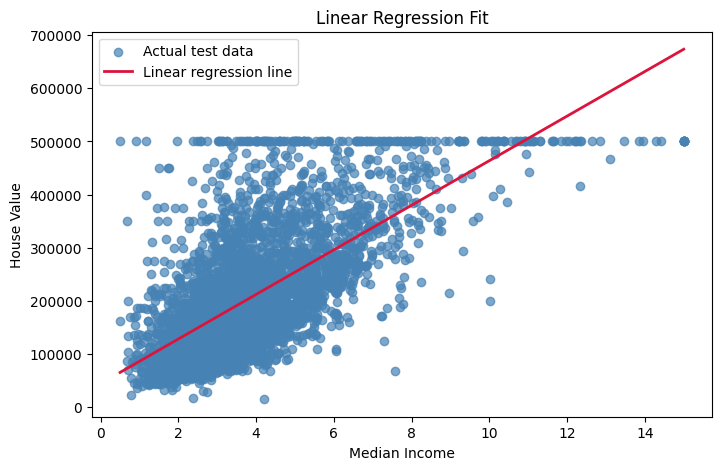

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort the test values so the regression line is drawn smoothly
x_plot = np.sort(X_test["Median_Income"].values)

# Keep the feature name when passing into the model to avoid scikit-learn warnings.
# A DataFrame with the same column name matches the training data schema.
x_plot_df = pd.DataFrame({"Median_Income": x_plot})
y_plot = model.predict(x_plot_df)

# Plot the real data points
plt.figure(figsize=(8, 5))
plt.scatter(X_test["Median_Income"], y_test, color="steelblue", alpha=0.7, label="Actual test data")

# Plot the fitted regression line
plt.plot(x_plot, y_plot, color="crimson", linewidth=2, label="Linear regression line")

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()